In [150]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay 

try:
    df_banca = pd.read_csv('BankChurners.csv')
    
    df_banca = df_banca.iloc[:, :-2]
    
    print("Dataset cargado correctamente.")
    display(df_banca.head())
except Exception as e:
    print(f"Todavía hay un pequeño salto: {e}")
  
print(df_banca.columns)


Dataset cargado correctamente.


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='str')


In [151]:
#pasamos todos los nombres de las columnas a minúsculas
df_banca.columns = [col.lower() for col in df_banca.columns]
print(df_banca.columns)

Index(['clientnum', 'attrition_flag', 'customer_age', 'gender',
       'dependent_count', 'education_level', 'marital_status',
       'income_category', 'card_category', 'months_on_book',
       'total_relationship_count', 'months_inactive_12_mon',
       'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
       'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt',
       'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio'],
      dtype='str')


In [152]:
# vamos a ver cuántos 'Unknown' hay en las columnas que nos interesan
columnas_interes = ['education_level', 'marital_status', 'income_category']

for col in columnas_interes:
    total_unknow = (df_banca[col] == 'Unknown').sum()
    print(f'en {col} hay un total de {total_unknow} valores desconocidos')

en education_level hay un total de 1519 valores desconocidos
en marital_status hay un total de 749 valores desconocidos
en income_category hay un total de 1112 valores desconocidos


Como podemos ver en las columnas de interés tenemos más de 3.000 resultados con valores nulos, es un problema grande porque no podemos tomar decisiones basadas en estos desconocidos, siempre es importante la calidad de los datos, así que en vez de rellenar voy a eliminar estas filas siempre y cuando tenga una buena cantidad de datos restantes para trabajar.

In [153]:
df_banca = df_banca[
    (df_banca['education_level'] != 'Unknown') &
    (df_banca['marital_status'] != 'Unknown') & 
    (df_banca['income_category'] != 'Unknown')
]

print('Total de registros iniciales: 10127')
print(f'Total registros ahora: {len(df_banca)}')
print(f'registros eliminados: {10127 - len(df_banca)}')


Total de registros iniciales: 10127
Total registros ahora: 7081
registros eliminados: 3046


In [154]:
df_banca[['customer_age', 'credit_limit']].describe()

,customer_age,credit_limit
count,7081.000000,7081.000000
mean,46.347691,8492.773831
std,8.041225,9126.072520
min,26.000000,1438.300000
25%,41.000000,2498.000000
50%,46.000000,4287.000000
75%,52.000000,10729.000000
max,73.000000,34516.000000


In [155]:
#clientes que se están yendo
df_banca['attrition_flag'].value_counts()

attrition_flag
Existing Customer    5968
Attrited Customer    1113
Name: count, dtype: int64

In [156]:
#niveles de educación
df_banca['education_level'].unique()

<StringArray>
[  'High School',      'Graduate',    'Uneducated',       'College',
 'Post-Graduate',     'Doctorate']
Length: 6, dtype: str

In [157]:
#vamos a ver si los clientes que se van tienen créditos bajitos
df_banca.groupby('attrition_flag')['credit_limit'].mean()

attrition_flag
Attrited Customer    8158.579964
Existing Customer    8555.099196
Name: credit_limit, dtype: float64

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16308\3326991606.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_banca, x='attrition_flag', palette= 'viridis')


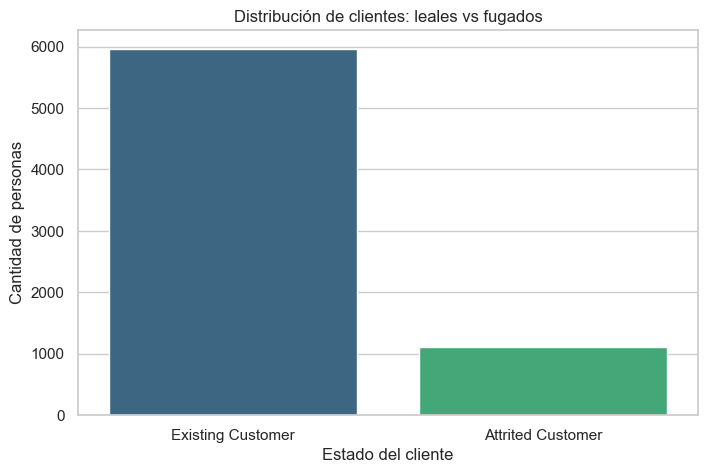

In [158]:
#vamos a crear nuestra primera gráfica para comparar a los clientes que se quedan con los que se van 
sns.set_theme(style='whitegrid')

#creamos una gráfica de conteo para ver la proporción de fuga 
plt.figure(figsize=(8, 5))
sns.countplot(data=df_banca, x='attrition_flag', palette= 'viridis')

plt.title('Distribución de clientes: leales vs fugados')
plt.xlabel('Estado del cliente')
plt.ylabel('Cantidad de personas')

plt.show()

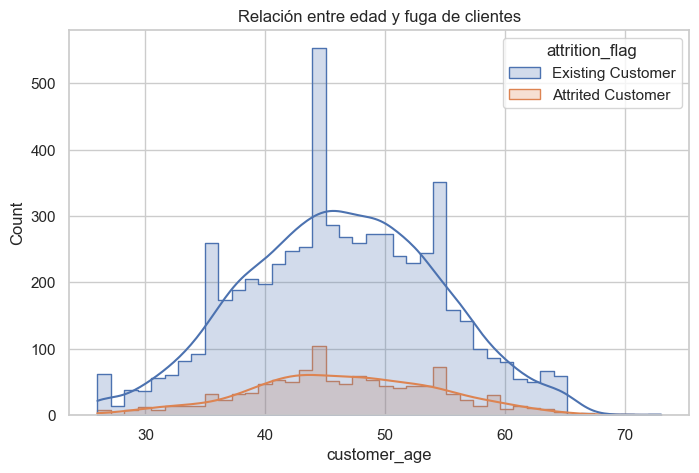

In [159]:
#vamos a ver si la edad influye en nuestros clientes fugados
plt.figure(figsize=(8, 5))
sns.histplot(data=df_banca, x='customer_age', hue='attrition_flag', kde=True, element='step')
plt.title('Relación entre edad y fuga de clientes')
plt.show()

al analizar la distribución por edad, observamos que la fuga de clientes no es aleatoria. Tiene un comportamiento gaussiano centrado en los 40 a 50 años, esto sugiere que la fuga de clientes se centra en personas en su etapa de mayor madurez financiera. 

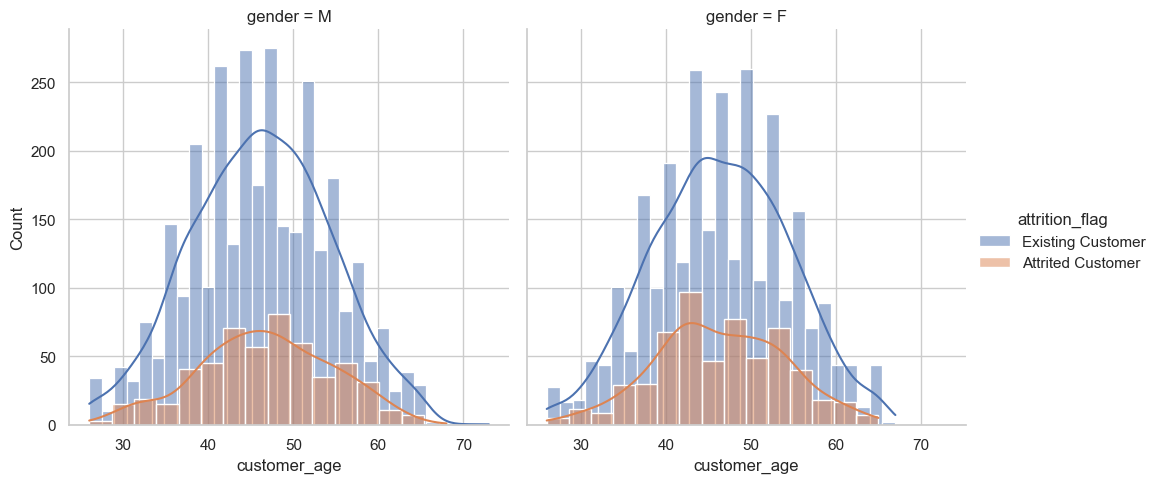

In [160]:
#ahora vamos a analizar también la edad con otra variable, vamos a ver si el genero también influye
#creamos gráficas espejo, una para hombres y otra para mujer
g = sns.FacetGrid(df_banca, col='gender', hue='attrition_flag', height=5)
g.map(sns.histplot, 'customer_age', kde=True)
g.add_legend()

Si miramos bien esta gráfica y nos fijamos en las barras naranjas, podemos observar que en los hombres (gender=M) estas barras son más bajas y están en un escalado más plano en comparación al de las mujeres(gender=f) dentro de la edad de 40 y 50 años, al parecer las mujeres están abandonando el banco en mayor proporción que los hombres en esta edad. 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16308\1462055397.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_banca, x='attrition_flag', y='credit_limit', palette='Set2')


Text(0, 0.5, 'límite de crédito')

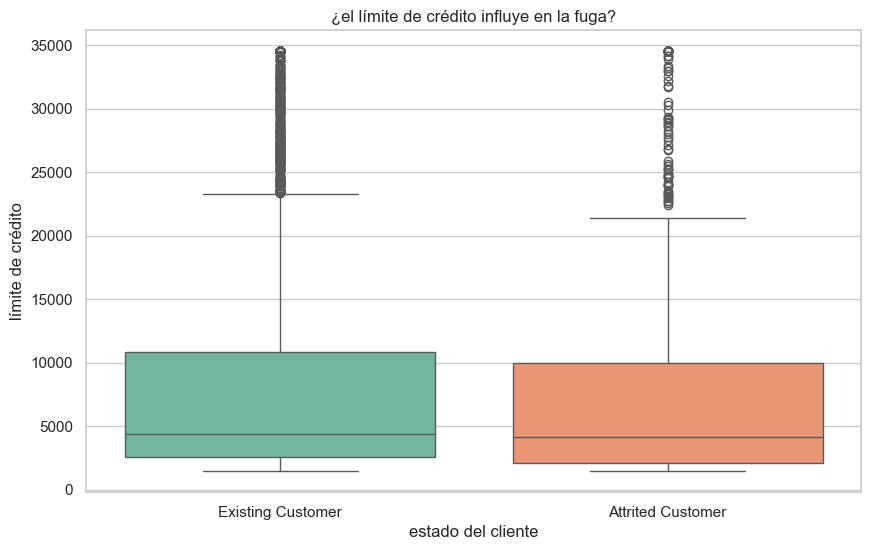

In [161]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df_banca, x='attrition_flag', y='credit_limit', palette='Set2')

plt.title('¿el límite de crédito influye en la fuga?')
plt.xlabel('estado del cliente')
plt.ylabel('límite de crédito')




C:\Users\Usuario\AppData\Local\Temp\ipykernel_16308\3702136991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df_banca, x='attrition_flag', y = 'total_trans_ct', palette='Set1')


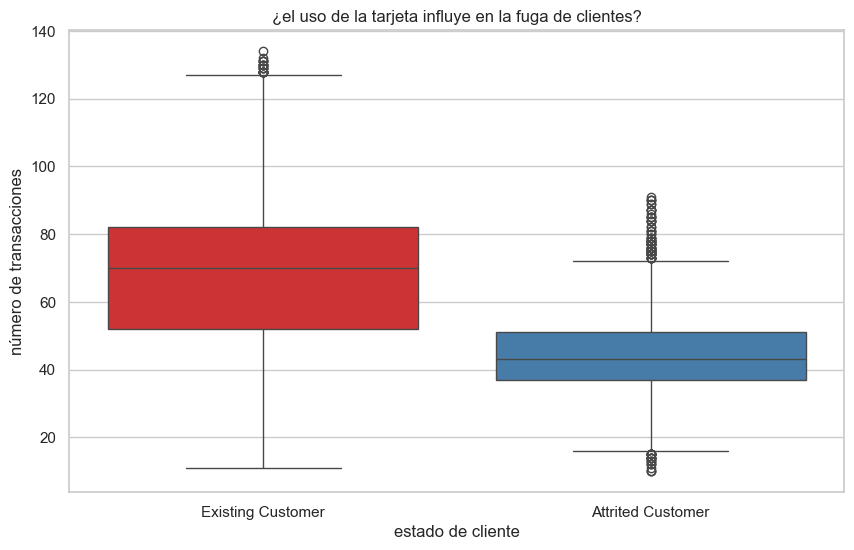

In [162]:
# ahora vamos a ver cuántas transacciones hacen los que se quedan comparado con los que se van (¿si alguien no usa la terjeta es por que se va a ir?)
plt.figure(figsize=(10, 6))
sns.boxplot(data= df_banca, x='attrition_flag', y = 'total_trans_ct', palette='Set1')

plt.title('¿el uso de la tarjeta influye en la fuga de clientes?')
plt.xlabel('estado de cliente')
plt.ylabel('número de transacciones')

plt.show()

Al parecer el uso de la tarjeta es una constante que nos ayuda a entender nuestra fuga de clientes, miremos con atención las cajas, la caja azul que es la de los clientes que se van está por debajo de la roja, casi me atrevo a decir que no se tocan, esto significa que el número de transacciones es un predictor muy bueno, si un cliente empieza a vahar de 50 transacciones es una señal de que se va a ir, los clientes que se van suelen hacer unas 45 transacciones, hay una brecha enorme entre las dos medias de las cajas en la gráfica. 

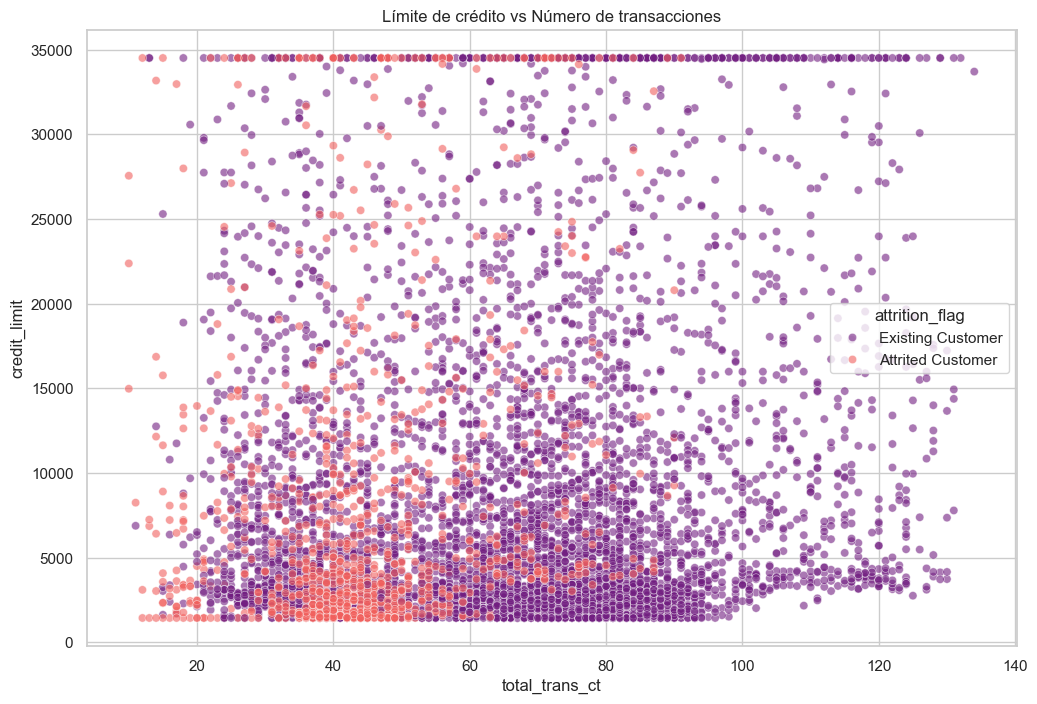

In [163]:
# ahora vamos a cruzar el límite de crédito contra el número de transacciones, la idea es ver si hay grupos de gente que se va(clústeres)
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_banca, 
    x='total_trans_ct',
    y= 'credit_limit',
    hue= 'attrition_flag',
    alpha=0.6,
    palette='magma'
)
    
plt.title('Límite de crédito vs Número de transacciones')
plt.show()


Como resultado final de este análisis podemos decir que:
-existe una concentración de abandonos en personas de 40 a 50 años
-al separar por genero encontramos que las mujeres tienen picos de fuga más marcados que los hombres.
-el banco tiene un problema de retención específicamente en clientes con una madurez financiera.
-las medianas de crédito entre los que se van y los que se quedad son casi iguales
-el uso de la tarjeta es el predictor número uno, los clientes que se quedan suelen superar las 70 transacciones, mientras que los que se van están por debajo de las 50 transacciones.

ALERTA: si un cliente baja su ritmo de uso es una señal de que abandonará la entidad.


In [164]:
# machine learning
# creamos un nuevo dataframe para nuestro modelo
df_modelo = pd.get_dummies(df_banca, columns=['gender', 'education_level', 'marital_status', 'income_category', 'card_category'])
df_modelo['attrition_flag'] = df_modelo['attrition_flag'].apply(lambda x:1 if x == 'Attrited Customer' else 0)

df_modelo.head()

,clientnum,attrition_flag,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,...,marital_status_Single,income_category_$120K +,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,card_category_Blue,card_category_Gold,card_category_Platinum,card_category_Silver
0,768805383,0,45,3,39,5,1,3,12691.0,777,...,False,False,False,True,False,False,True,False,False,False
1,818770008,0,49,5,44,6,1,2,8256.0,864,...,True,False,False,False,False,True,True,False,False,False
2,713982108,0,51,3,36,4,1,0,3418.0,0,...,False,False,False,False,True,False,True,False,False,False
4,709106358,0,40,3,21,5,1,0,4716.0,0,...,False,False,False,True,False,False,True,False,False,False
5,713061558,0,44,2,36,3,1,2,4010.0,1247,...,False,False,True,False,False,False,True,False,False,False


In [165]:
target = df_modelo['attrition_flag']
features = df_modelo.drop(['attrition_flag', 'clientnum'], axis=1)

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=12345)

print(f'Total features: {features.shape[1]}' )
print(f'Muetras para entrenamiento: {target_train.shape[0]}') 


Total features: 34
Muetras para entrenamiento: 5664


In [166]:
model = RandomForestClassifier()
model.fit(features_train, target_train)

predictions = model.predict(features_test)
print(classification_report(target_test, predictions))  

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1185
           1       0.94      0.75      0.83       232

    accuracy                           0.95      1417
   macro avg       0.94      0.87      0.90      1417
weighted avg       0.95      0.95      0.95      1417



OJO: Durante el desarrollo, identifiqué un desbalance de clases causado por un error en el etiquetado de datos (Attrited vs Attrition). Al corregirlo, el modelo pasó de una precisión falsa del 100% a un modelo productivo del 95%.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16308\3054910640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')


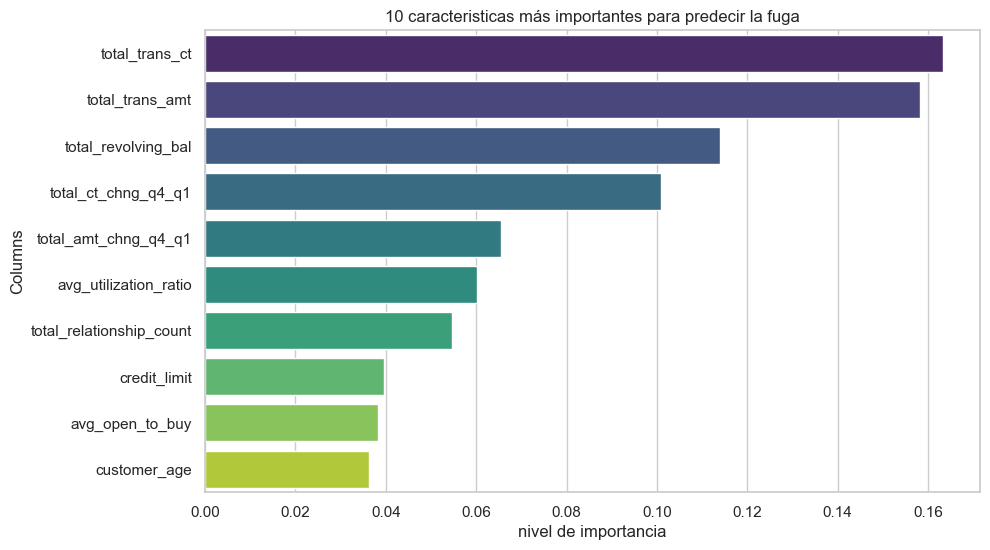

In [167]:
#buscamos importancias 
importancias = pd.Series(model.feature_importances_, index=features_train.columns)
importancias = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')
plt.title('10 caracteristicas más importantes para predecir la fuga')
plt.xlabel('nivel de importancia')
plt.ylabel('Columns')
plt.show()

Como resultado de nuestro modelo entrenado, tenemos una precisión de 0.95, esto quiere decir que, si el modelo marca a un cliente, el banco puede estar un 95% seguro de que no es una falsa alarma (ahorrando dinero en campañas de marketing).
El recall de 0.76 significa que logramos identificar al 76% de clientes que se van. Es una red de seguridad sólida que se puede mejorar con más datos. 
Para ecplicar la gráfica de importancias podemos deducir que: si un cliente deja de usar su tarjeta es la señal más clara de que podría irse, lo vemos en la columna total_trans_amt y total_trans_ct.
Análisis de retención predictiva: mediante este modelo de Random Forest, podemos deducir que la fuga de clientes no está ligada a sus características demográficas (edad o salario), sino a su actividad en transacciones, un descenso en el volumen de transacciones trimestrales es el predictor más fuerte.
Recomendación de negocio: el banco no debería enfocarse en dar más crédito, sino incentivar el uso de las tarjetas de crédito, si se puede incentivar de una manera cotidiana mucho mejor, mediante beneficios, de esta manera atacamos directamente la raíz de la deserción detectada por nuestro modelo. 


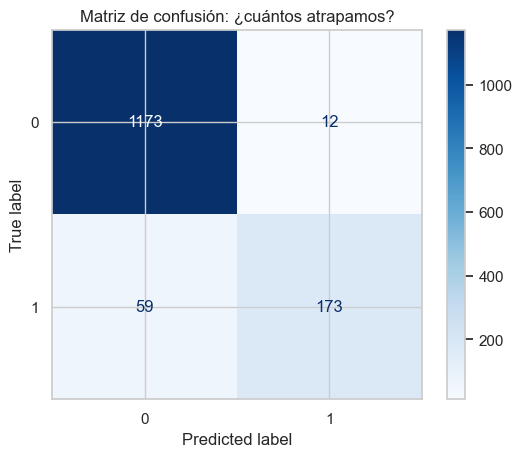

In [168]:
cm = confusion_matrix(target_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión: ¿cuántos atrapamos?')

plt.show()

El modelo dijo que clientes se quedaban y acertó 1173 veces, el modelo predijo clientes que se iban y acertó 173 veces, tan solo se escaparon 59 fugas. En conclusión logramos detectar 173 clientes de los 232 que se fugaban. 